Importowanie wymaganych bibliotek:
cv2 - biblioteka OpenCV
matplotlib - biblioteka do rysowania wykresów
numpy - biblioteka NumPy

# Biblioteka OpenCV
OpenCV (Open Source Computer Vision Library) to darmowa biblioteka zawierająca implementację wielu algorytmów służących do przetwarzania obrazu video.

Wersja i przykład użycia biblioteki:

In [1]:
import cv2 as cv
from matplotlib import pyplot as pl
import numpy as np
print(cv.__version__)

4.13.0


Załadowany obraz z pliku (np. jpg) jest tablicą typu numpy

In [4]:
img = cv.imread('./Images/tiger.jpg')
print(type(img)) 

<class 'numpy.ndarray'>


## Konwersja modelu barw
Domyślnie OpenCV używa odwrotnego modelu barw BGR, zamiast RGB. Aby prawidłowo wyświetlać obraz należy podczas wywołania funkcji imshow użyć odpowiedniej konwersji.

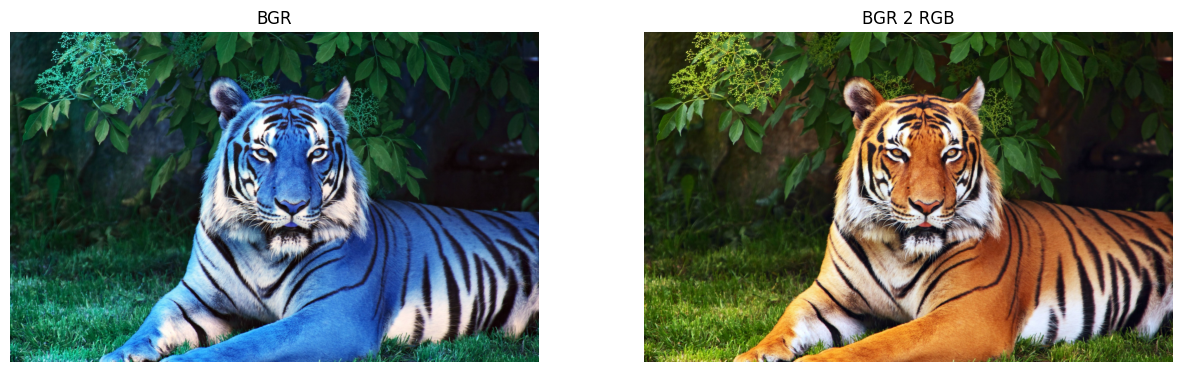

In [5]:
f,ax = pl.subplots(1,2,figsize=[15,15])
ax[0].axis('off')
ax[0].imshow(img)
ax[0].set_title("BGR")
ax[1].axis('off')
ax[1].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[1].set_title("BGR 2 RGB")
pl.show()

### Filtry OpenCV

Biblioteka OpenCV zawira gotowe metody umożliwiające stosowanie standardowych filtrów:
- Filtry dolno i górnoprzepustowe
- Filtry krawędziowe, konturowe
- Filtry statystyczne np. medianowe, minimalny, maksymalny

Przeanalizuj poniższe przykłady:

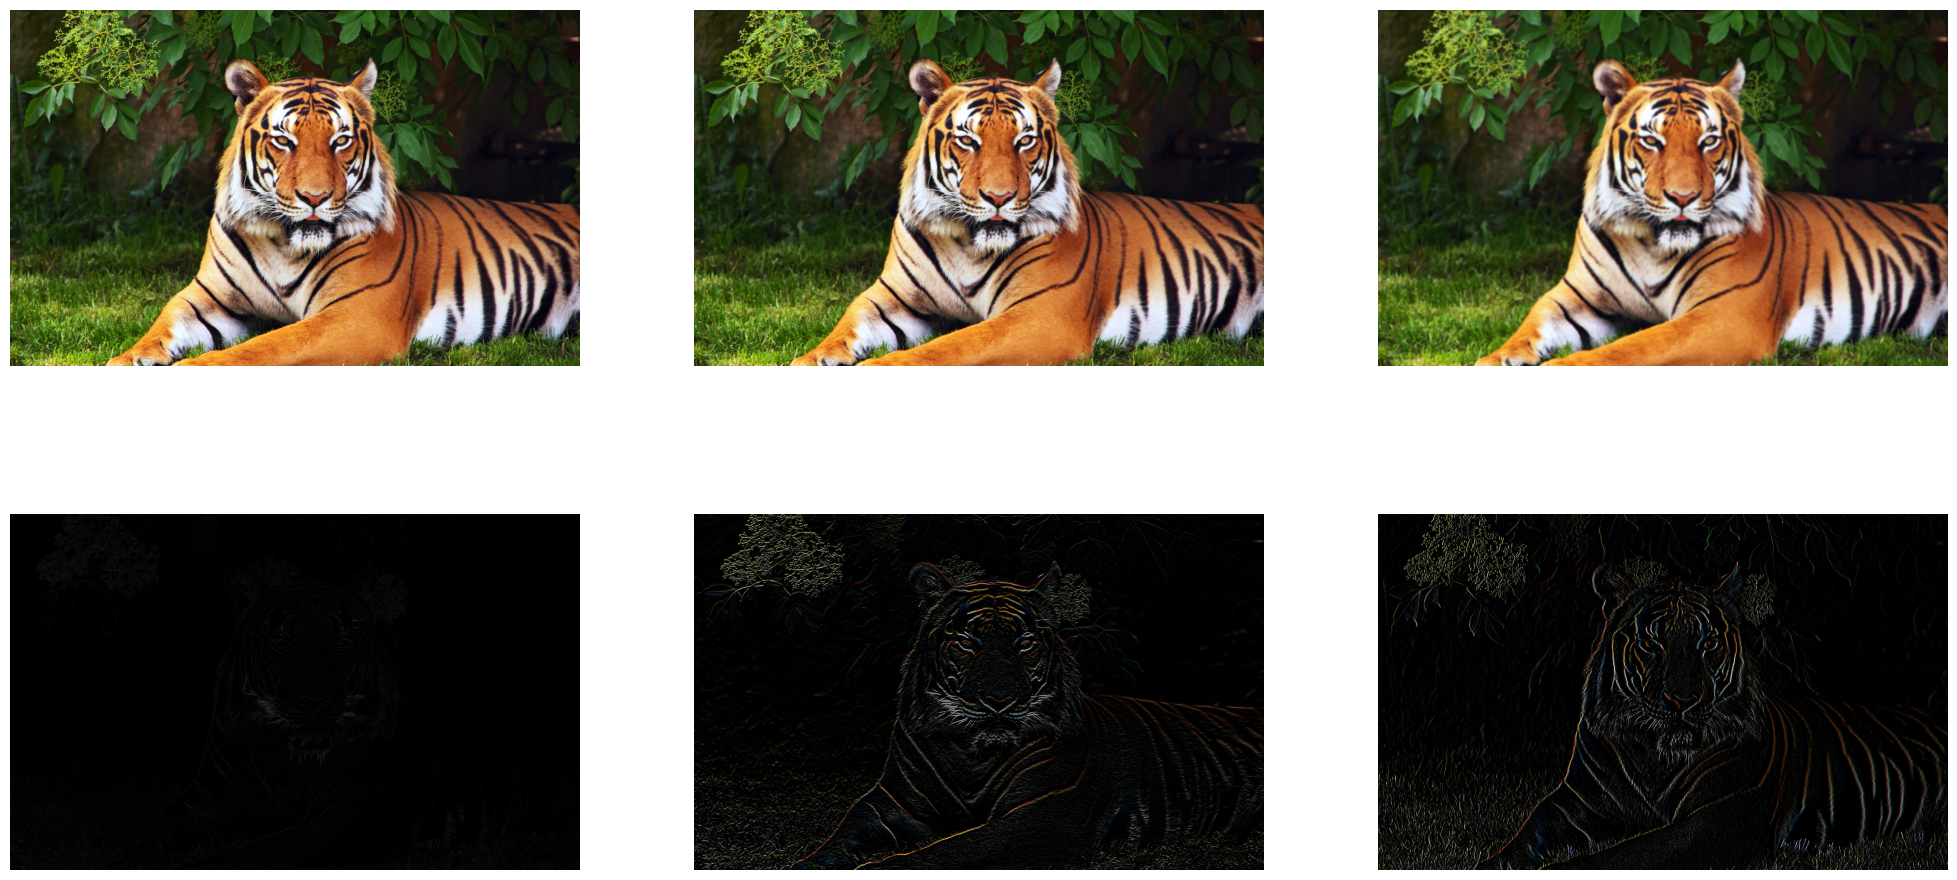

In [7]:
img = cv.imread('./Images/tiger.jpg')

k0 = np.array([[0, 0, 0],[0, 1, 0],[0, 0, 0]])
k1 = np.array([[1, 1, 1],[1, 1, 1],[1, 1, 1]])/9
k2 = np.ones((10,10),np.single)/100
k3 = np.array([[1, -1, 1],[-1,0, -1],[1, -1, 1]])
k4 = np.array([[-1, -1, -1],[0, 0, 0],[1, 1, 1]])
k5 = k4.transpose()
#print (k)

kernels = [k0,k1,k2,k3,k4,k5]

f,s = pl.subplots(2,3,figsize=[25,12])
s.shape = (1,6)
i=0
s = s[0]

for ax in s:
    nimg = cv.filter2D(src=img, ddepth=-1, kernel=kernels[i])
    ax.imshow(cv.cvtColor(nimg, cv.COLOR_BGR2RGB))
    ax.axis("off")
    i=i+1

pl.show()

### Filtr medianowy

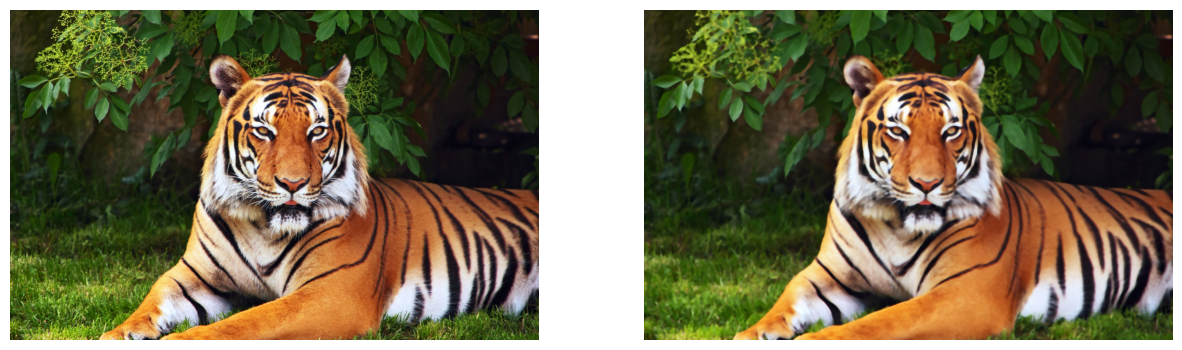

In [8]:
img2 = cv.medianBlur(img, 15)

f,s = pl.subplots(1,2,figsize=[15,15])
s[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
s[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
s[0].axis('off')
s[1].axis('off')
pl.show()

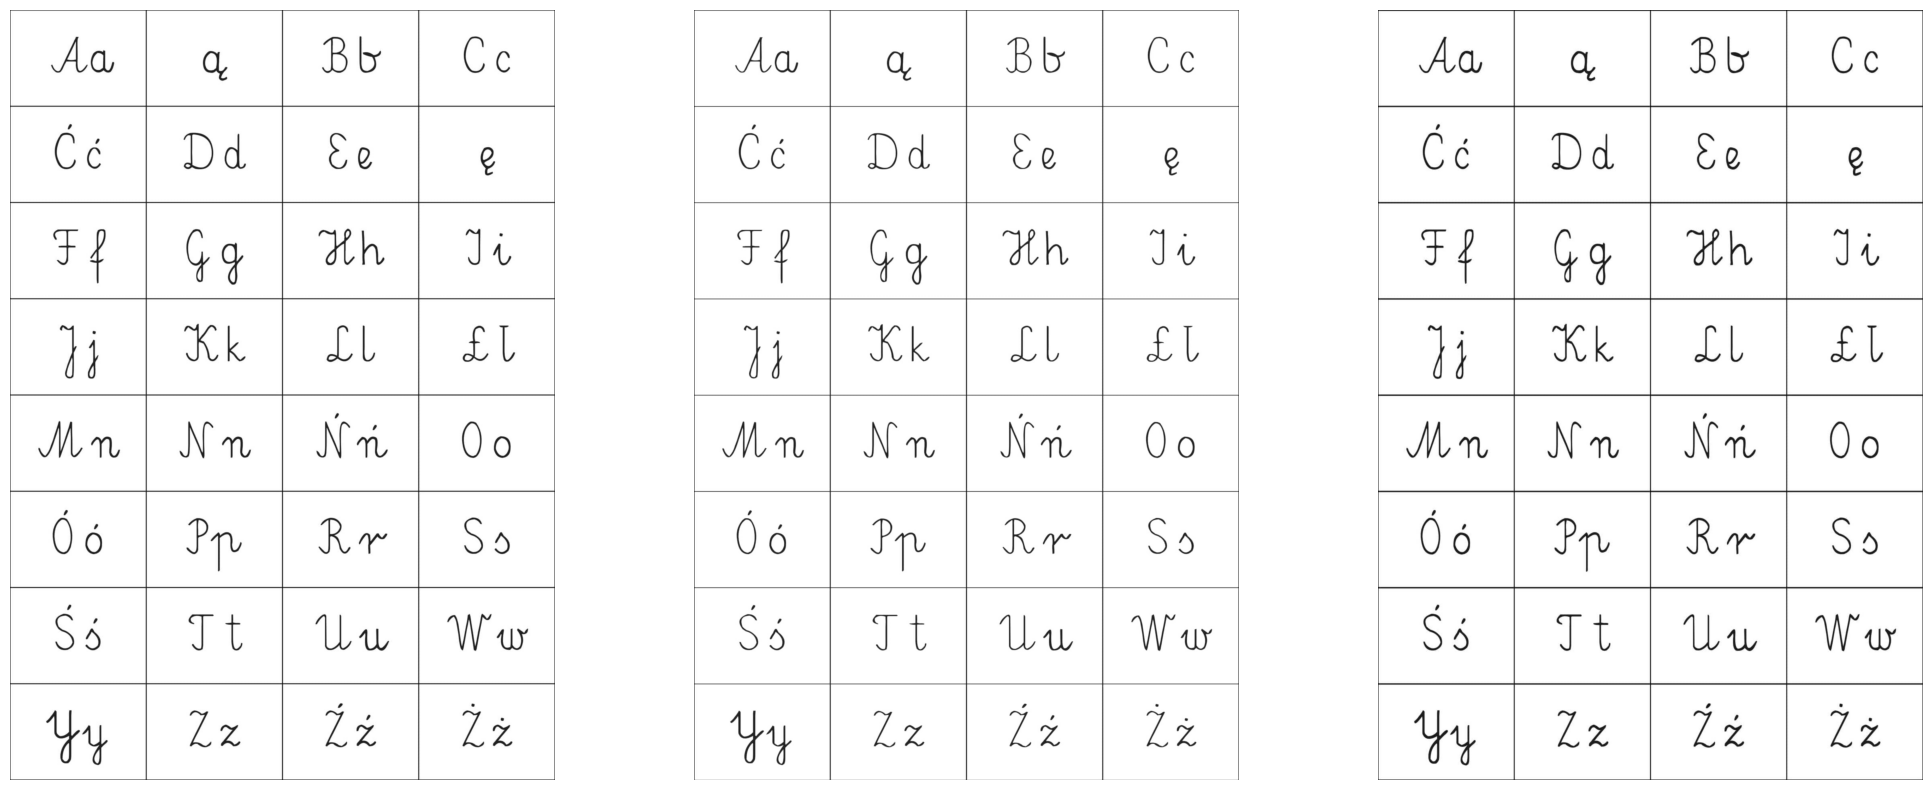

In [10]:
img = cv.imread('./Images/litery.jpg')
img2 = cv.dilate(img, (3,3), 0) #max
img3 = cv.erode(img, (3,3), 0) #min
f,ax = pl.subplots(1,3,figsize=[25,10])
ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
ax[2].imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
pl.show()

### Filtr Gaussa

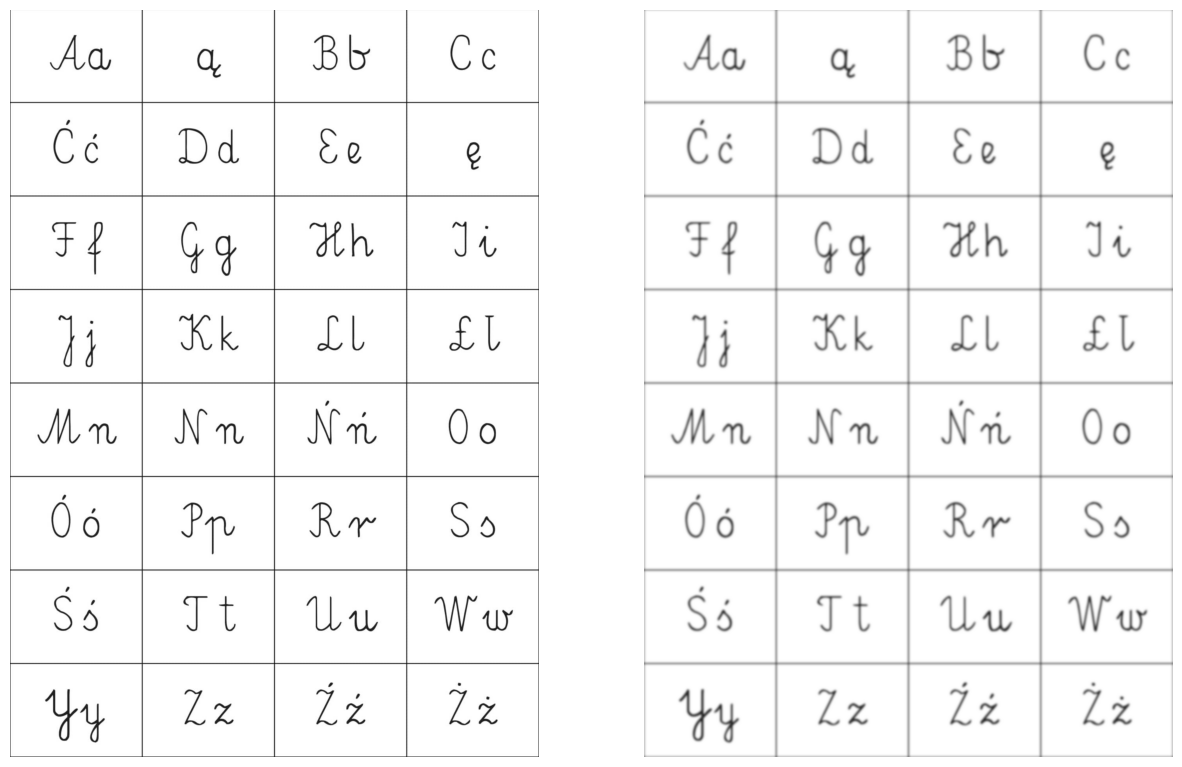

In [11]:

img2 = cv.GaussianBlur(img, (15,15), 0)

f,s = pl.subplots(1,2,figsize=[15,15])
s[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
s[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
s[0].axis('off')
s[1].axis('off')
pl.show()

### Binaryzacja obrazów
Binaryzacja obrazu, czyli tzw. progowanie, służy do utworzenia dwukolorowego, binarnego, czarno-białego obrazu, z obrazu, który oryginalnie zapisany jest np. w 256 odcieniach szarości

Przykłady binaryzacji (OpenCV):

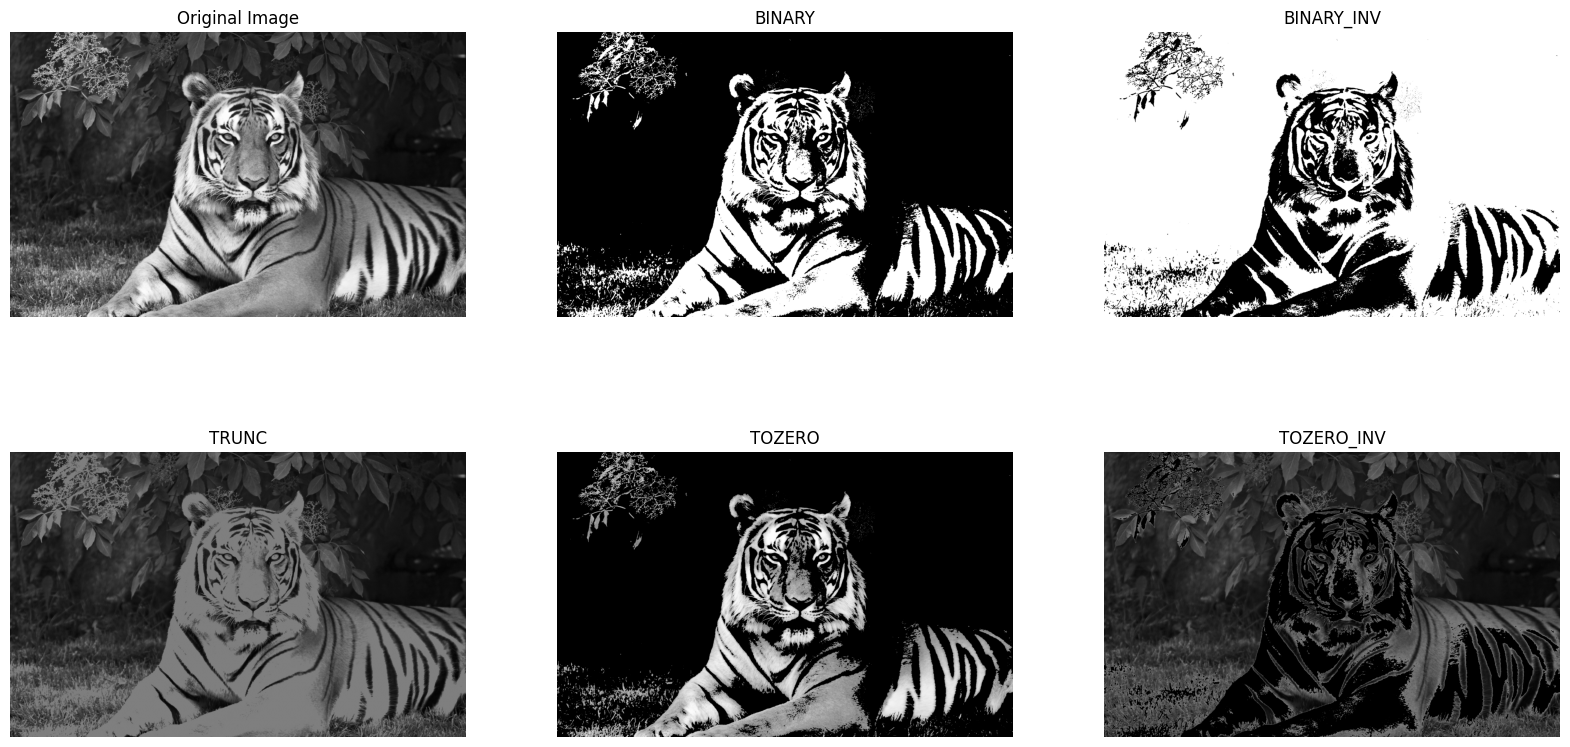

In [13]:
img = cv.imread('./Images/tiger.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

r, thr1 = cv.threshold(gray,127,255,cv.THRESH_BINARY)
r, thr2 = cv.threshold(gray,127,255,cv.THRESH_BINARY_INV)
r, thr3 = cv.threshold(gray,127,255,cv.THRESH_TRUNC)
r, thr4 = cv.threshold(gray,127,255,cv.THRESH_TOZERO)
r, thr5 = cv.threshold(gray,127,255,cv.THRESH_TOZERO_INV)

ttls = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [gray, thr1, thr2, thr3, thr4, thr5]

pl.figure(figsize=[20,10])
for i in range(6):
    pl.subplot(2,3,i+1)
    pl.imshow(images[i],'gray',vmin=0,vmax=255)
    pl.title(ttls[i])
    pl.axis('off')
    

### Binaryzacja adaptacyjna

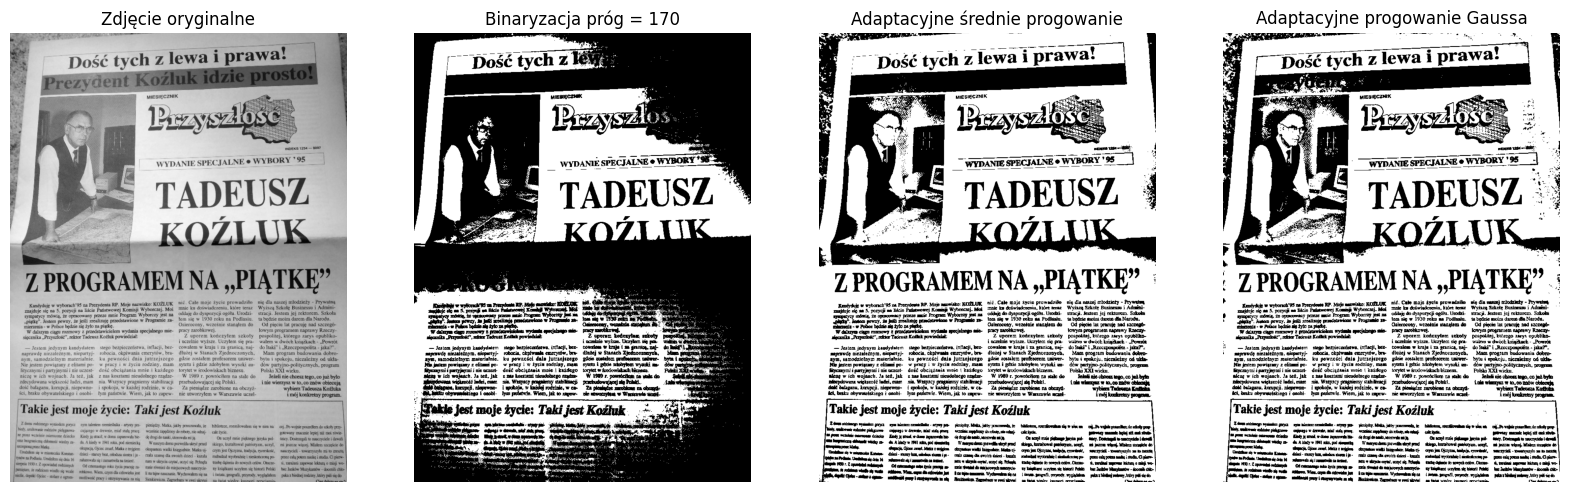

In [14]:
img = cv.imread('./Images/gazeta.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

pr = 170
ret,th1 = cv.threshold(gray,pr,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,123,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,123,2)

titles = ['Zdjęcie oryginalne', f'Binaryzacja próg = {pr}','Adaptacyjne średnie progowanie', 'Adaptacyjne progowanie Gaussa']

images = [gray, th1, th2, th3]
pl.figure(figsize=[20,8])

for i in range(4):
    pl.subplot(1,4,i+1),pl.imshow(images[i],'gray')
    pl.title(titles[i])
    pl.axis('off')    
pl.show()